### Import Packages

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from keras.models import Sequential, load_model
from keras.layers import Input, Dense
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping

seed = 42
os.environ['PYTHONHASHSEED'] = str(seed)
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

print("TensorFlow version: ", tf.__version__)
print("Number of GPUs available: ", len(tf.config.list_physical_devices('GPU')))

TensorFlow version:  2.19.0
Number of GPUs available:  1


### Data Preprocessing

In [3]:
cols = ['u_e','u_n']
scaled_cols = ['scaled_' + col for col in cols]

# Load datasets
df_stn = pd.read_csv('Sikorsky_data.csv')
df_stn = df_stn.rename(columns={'WSPD':'u'})
df_stn['TmStamp'] = pd.to_datetime(df_stn['TmStamp'], format='mixed')
df_stn.set_index('TmStamp', inplace=True)

df_buoy = pd.read_csv('WLIS_data.csv')
df_buoy = df_buoy.rename(columns={'WSPD':'u'})
df_buoy['TmStamp'] = pd.to_datetime(df_buoy['TmStamp'], format='mixed')
df_buoy.set_index('TmStamp', inplace=True)

# Add east and north components
alpha = -13
df_stn['rad'] = np.pi/180 * ((alpha + 630 - df_stn['WDIR']) % 360)
df_stn['u_e'] = df_stn['u'] * np.cos(df_stn['rad'])
df_stn['u_n'] = df_stn['u'] * np.sin(df_stn['rad'])

df_buoy['rad'] = np.pi/180 * ((alpha + 630 - df_buoy['WDIR']) % 360)
df_buoy['u_e'] = df_buoy['u'] * np.cos(df_buoy['rad'])
df_buoy['u_n'] = df_buoy['u'] * np.sin(df_buoy['rad'])

# df_test: [2024-07-01 00:00:00 ~ 2025-06-30 23:00:00]
split = pd.to_datetime('2024-06-30 23:59:00')
df_stn_train = df_stn[df_stn.index < split]
df_stn_test = df_stn[df_stn.index > split]

df_buoy_train = df_buoy[df_buoy.index < split]
df_buoy_test = df_buoy[df_buoy.index > split]

# Data normalization
scaled_stn_wind, scaled_buoy_wind = MinMaxScaler(), MinMaxScaler()
df_stn_train, df_stn_test = df_stn_train.copy(), df_stn_test.copy()
df_stn_train.loc[:, scaled_cols] = scaled_stn_wind.fit_transform(df_stn_train[cols])
df_stn_test.loc[:, scaled_cols] = scaled_stn_wind.transform(df_stn_test[cols])

df_buoy_train, df_buoy_test = df_buoy_train.copy(), df_buoy_test.copy()
df_buoy_train.loc[:, scaled_cols] = scaled_buoy_wind.fit_transform(df_buoy_train[cols])
df_buoy_test.loc[:, scaled_cols] = scaled_buoy_wind.transform(df_buoy_test[cols])

# Train-Test split
X_train, y_train = df_stn_train[scaled_cols].values, df_buoy_train[scaled_cols].values
X_test, y_test = df_stn_test[scaled_cols].values, df_buoy_test[scaled_cols].values

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(114768, 2) (114768, 2)
(8760, 2) (8760, 2)


### Model Training

I0000 00:00:1759276157.393114  537116 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38483 MB memory:  -> device: 0, name: NVIDIA A100-PCIE-40GB, pci bus id: 0000:e2:00.0, compute capability: 8.0
I0000 00:00:1759276158.668235  537698 service.cc:152] XLA service 0x7f4dc0004a90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1759276158.668275  537698 service.cc:160]   StreamExecutor device (0): NVIDIA A100-PCIE-40GB, Compute Capability 8.0
2025-09-30 19:49:18.686429: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1759276158.771486  537698 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1759276159.719756  537698 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


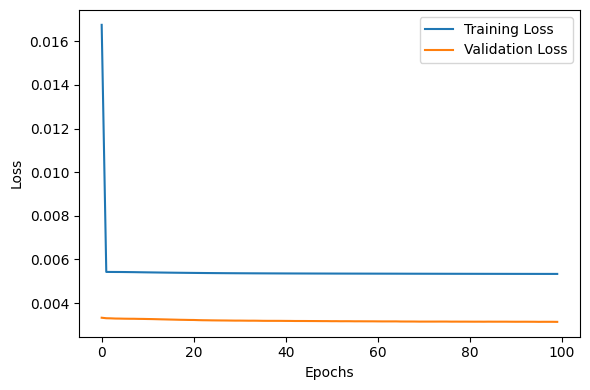

In [4]:
model_file = 'wind_MLP.keras'

model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='leaky_relu'),
    Dense(64, activation='leaky_relu'),
    Dense(y_train.shape[1])
])

model.compile(optimizer=Adam(learning_rate=1e-4), loss='mse')

# Train and save the model (architecture + weights)
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=100, batch_size=64, validation_split=0.1, callbacks=[es], verbose=0)
model.save(model_file)

# Plot the training & validation loss over epochs
plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

### Model Evaluation

In [5]:
# Load the saved model
model = load_model(model_file)

# Training error
y_pred1 = model.predict(X_train, verbose=0)
y_pred1_uc = scaled_buoy_wind.inverse_transform(y_pred1)
y_pred1_u = np.sqrt(y_pred1_uc[:, 0]**2 + y_pred1_uc[:, 1]**2)
y_true1_uc = scaled_buoy_wind.inverse_transform(y_train)

mae_uc1 = mean_absolute_error(y_true1_uc, y_pred1_uc, multioutput='raw_values')
mae_u1 = mean_absolute_error(df_buoy_train['u'], y_pred1_u)
print('Training MAE (u_e, u_n):', ', '.join([f'{mae:.3f}' for mae in mae_uc1]))
print(f'Training MAE (u): {mae_u1:.3f}')

rmse_uc1 = np.sqrt(mean_squared_error(y_true1_uc, y_pred1_uc, multioutput='raw_values'))
rmse_u1 = np.sqrt(mean_squared_error(df_buoy_train['u'], y_pred1_u))
print('Training RMSE (u_e, u_n):', ', '.join([f'{rmse:.3f}' for rmse in rmse_uc1]))
print(f'Training RMSE (u): {rmse_u1:.3f}')

# Test error
y_pred2 = model.predict(X_test, verbose=0)
y_pred2_uc = scaled_buoy_wind.inverse_transform(y_pred2)
y_pred2_u = np.sqrt(y_pred2_uc[:, 0]**2 + y_pred2_uc[:, 1]**2)
y_true2_uc = scaled_buoy_wind.inverse_transform(y_test)

mae_uc2 = mean_absolute_error(y_true2_uc, y_pred2_uc, multioutput='raw_values')
mae_u2 = mean_absolute_error(df_buoy_test['u'], y_pred2_u)
print('Test MAE (u_e, u_n):', ', '.join([f'{mae:.3f}' for mae in mae_uc2]))
print(f'Test MAE (u): {mae_u2:.3f}')

rmse_uc2 = np.sqrt(mean_squared_error(y_true2_uc, y_pred2_uc, multioutput='raw_values'))
rmse_u2 = np.sqrt(mean_squared_error(df_buoy_test['u'], y_pred2_u))
print('Test RMSE (u_e, u_n):', ', '.join([f'{rmse:.3f}' for rmse in rmse_uc2]))
print(f'Test RMSE (u): {rmse_u2:.3f}')

Training MAE (u_e, u_n): 2.704, 2.357
Training MAE (u): 2.549
Training RMSE (u_e, u_n): 3.738, 3.166
Training RMSE (u): 3.326
Test MAE (u_e, u_n): 2.258, 1.965
Test MAE (u): 2.443
Test RMSE (u_e, u_n): 2.856, 2.521
Test RMSE (u): 2.958
